# Analyse radio / Chandra d’un amas

Choisir `CLUSTER_ID` et `SIZE` dans la cellule **Paramètres**, puis exécuter toutes les cellules.
Ce notebook montre les FITS natifs, le crop centré radio, Chandra reprojeté sur ce crop,
la moyenne par blocs et la normalisation utilisée à l’entraînement. Aucune data augmentation
n’est appliquée. Il fonctionne également sans fichier Chandra ou sans recouvrement.

Utiliser le même environnement Python que `clusterprep` (avec Jupyter/IPykernel).
Le notebook retrouve le projet depuis sa racine ou depuis `clusterprep/notebooks`.
Les FITS sources ne sont jamais modifiés.

In [1]:
from pathlib import Path
import sys
import json
import warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import AsinhNorm, Normalize
from matplotlib.patches import Rectangle
from astropy.table import Table
from astropy.wcs import FITSFixedWarning
from IPython.display import display
from reproject import reproject_interp

PROJECT_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
                     if (p / "clusterprep/src/clusterprep").is_dir()), None)
if PROJECT_ROOT is None:
    raise RuntimeError("Ouvrir ce notebook depuis PH_Project_I ou un de ses sous-dossiers.")
sys.path.insert(0, str(PROJECT_ROOT / "clusterprep/src"))
from clusterprep import get_data_info_dict, load_celestial_fits, normalize, load_processed
from clusterprep.preprocessing import centered_raw_window, block_average

plt.rcParams.update({"figure.dpi": 100, "font.size": 10})
print("Projet :", PROJECT_ROOT)

Projet : /Users/antoinegdrn/PH_Project_I


## Paramètres

`CLUSTER_ID` accepte l’identifiant exact, avec ou sans `.fits`. `None` sélectionne
le premier amas apparié disponible. La liste des identifiants apparaît ci-dessous.
Les percentiles 30–99 et `ALPHA=10` correspondent aux valeurs actuelles du Dataset.
Les modifier ici permet d’explorer la normalisation, sans modifier l’entraînement.

`VERIFY_CACHE=True` compare les images reconstruites au cache persistant et le crée
s’il manque. Les images intermédiaires ne sont pas stockées dans le cache : leur
reconstruction dans ce notebook reste nécessaire pour les visualiser.

In [2]:
DATA_DIR = PROJECT_ROOT / "scratch/data/PSZ2/classified"
CLUSTER_ID = "PSZ2G023.17+86.71"
SIZE = 128
PERCENTILE_LO = 30
PERCENTILE_HI = 99
ALPHA = 10.0
PROCESSED_DIR = PROJECT_ROOT / "processed"
VERIFY_CACHE = False
EXPORT_FIGURES = False
OUTPUT_ROOT = PROJECT_ROOT / "results/cluster_analysis"

In [3]:
data_info = get_data_info_dict(DATA_DIR)
paired_ids = [v["cluster_id"] for v in data_info.values() if v["chandra_path"]]
print(f"{len(data_info)} amas radio, dont {len(paired_ids)} avec Chandra.")
print("Exemples appariés :", ", ".join(paired_ids[:12]))
# Pour voir tous les identifiants :
# display(Table(rows=[(v["cluster_id"], v["class"], bool(v["chandra_path"]))
#                     for v in data_info.values()], names=["Amas", "Classe", "Chandra"]))
selected = CLUSTER_ID
if selected is None:
    selected = paired_ids[0] if paired_ids else next(iter(data_info.values()))["cluster_id"]
selected = str(selected).removesuffix(".fits")
matches = [v for v in data_info.values() if v["cluster_id"] == selected]
if len(matches) != 1:
    suggestions = [v["cluster_id"] for v in data_info.values()
                   if selected.lower() in v["cluster_id"].lower()]
    raise ValueError(f"Amas non trouvé ou ambigu : {selected}. Correspondances : {suggestions[:20]}")
info = matches[0]
has_chandra = bool(info["chandra_path"])
print(json.dumps(info, indent=2, ensure_ascii=False))
OUTPUT_DIR = OUTPUT_ROOT / info["cluster_id"]

207 amas radio, dont 85 avec Chandra.
Exemples appariés : PSZ2G023.17+86.71, PSZ2G031.93+78.71, PSZ2G040.58+77.12, PSZ2G046.88+56.48, PSZ2G048.10+57.16, PSZ2G049.32+44.37, PSZ2G053.53+59.52, PSZ2G055.59+31.85, PSZ2G056.77+36.32, PSZ2G057.61+34.93, PSZ2G066.41+27.03, PSZ2G071.39+59.54
{
  "cluster_id": "PSZ2G023.17+86.71",
  "raw_path": "/Users/antoinegdrn/PH_Project_I/scratch/data/PSZ2/classified/RAW/DE/PSZ2G023.17+86.71.fits",
  "chandra_path": "/Users/antoinegdrn/PH_Project_I/scratch/data/PSZ2/classified/CHANDRA/DE/PSZ2G023.17+86.71CHANDRA.fits",
  "name": "PSZ2G023.17+86.71.fits",
  "class": "DE",
  "size": "21240000"
}


## 1. FITS d’origine et fenêtre radio

Les valeurs natives ne sont pas normalisées pour le modèle. Pour révéler les
structures, **l’affichage uniquement** utilise un étirement asinh entre les
percentiles 1 et 99. Les barres de couleur restent dans les unités des FITS
(`BUNIT` si présent). Les NaN sont gris. Le rectangle cyan délimite le crop
radio employé par la chaîne d’entraînement ; il ne représente pas une taille
physique fixe entre amas.

In [4]:
with warnings.catch_warnings(record=True) as fits_warnings:
    warnings.simplefilter("always", FITSFixedWarning)
    raw_native, raw_header, raw_wcs = load_celestial_fits(info["raw_path"])
    if has_chandra:
        chandra_native, chandra_header, chandra_wcs = load_celestial_fits(info["chandra_path"])
    else:
        chandra_native = chandra_header = chandra_wcs = None
for item in fits_warnings:
    if not issubclass(item.category, FITSFixedWarning):
        warnings.warn(str(item.message), item.category)
print(f"{sum(issubclass(w.category, FITSFixedWarning) for w in fits_warnings)} avertissements WCS "
      "(détails consultables dans fits_warnings).")
if not isinstance(SIZE, int) or SIZE < 1:
    raise ValueError("SIZE doit être un entier positif")
ratio = min(raw_native.shape) // SIZE
if ratio < 1:
    raise ValueError(f"Image radio {raw_native.shape} trop petite pour SIZE={SIZE}")
factor = 1 << (ratio.bit_length() - 1)
window = centered_raw_window(raw_native.shape, SIZE, factor)
# Même conversion float32 que read_fits_with_wcs dans le prétraitement.
raw_crop = raw_native.astype(np.float32)[window]
window_wcs = raw_wcs.slice(window)
small_wcs = raw_wcs.slice(tuple(slice(s.start, s.stop, factor) for s in window))
raw_unit = str(raw_header.get("BUNIT", "unité FITS non renseignée"))
chandra_unit = str(chandra_header.get("BUNIT", "unité FITS non renseignée")) if has_chandra else ""
print(f"Crop : y={window[0]}, x={window[1]} ; moyenne par blocs {factor}×{factor} → {SIZE}×{SIZE}")

1 avertissements WCS (détails consultables dans fits_warnings).
Crop : y=slice(128, 2176, None), x=slice(128, 2176, None) ; moyenne par blocs 16×16 → 128×128


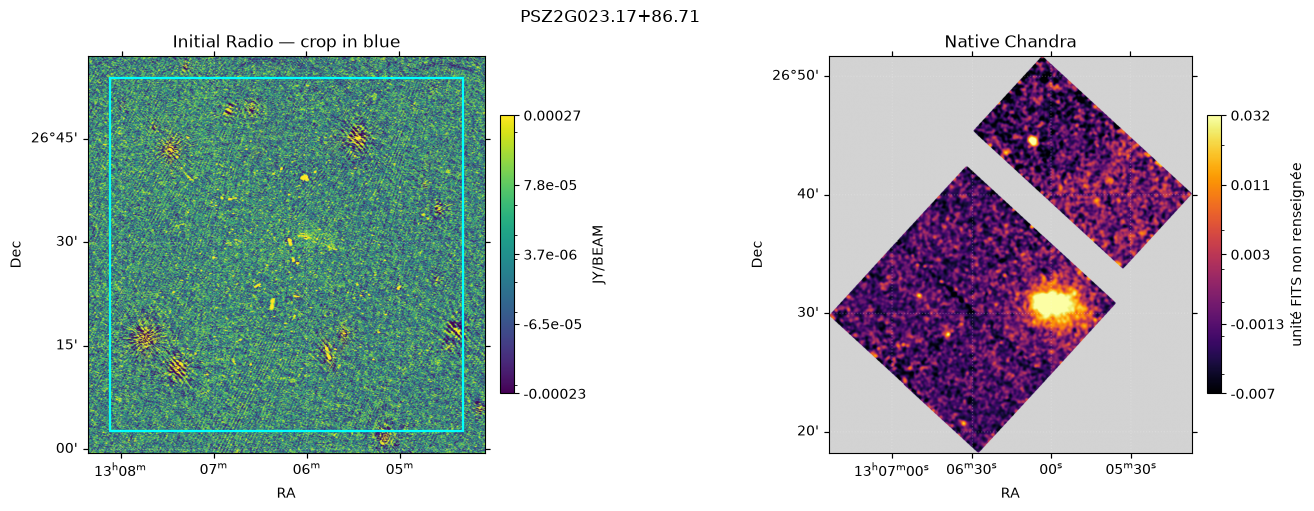

In [9]:
def display_norm(data):
    values = np.asarray(data)[np.isfinite(data)]
    lo, hi = np.percentile(values, [1, 99]) if values.size else (0., 1.)
    if hi <= lo:
        hi = lo + max(abs(lo) * 1e-6, 1e-8)
    return AsinhNorm(linear_width=(hi - lo) / 10, vmin=lo, vmax=hi)


def panel(fig, rows, cols, index, data, title, wcs=None, unit="", cmap="viridis", norm=None):
    ax = fig.add_subplot(rows, cols, index, projection=wcs)
    palette = plt.get_cmap(cmap).copy()
    palette.set_bad("lightgray")
    artist = ax.imshow(np.ma.masked_invalid(data), origin="lower", cmap=palette,
                       norm=display_norm(data) if norm is None else norm)
    ax.set_title(title)
    if wcs is not None:
        ax.set_xlabel("RA")
        ax.set_ylabel("Dec")
        ax.coords.grid(color="white", alpha=.2, ls=":")
    else:
        ax.set_xlabel("Pixel x")
        ax.set_ylabel("Pixel y")
    ticks = artist.norm.inverse(np.linspace(0, 1, 5))
    fig.colorbar(artist, ax=ax, shrink=.7, pad=.03, label=unit,
                 ticks=ticks, format="%.2g")
    return ax


def show_figure(fig, filename):
    if EXPORT_FIGURES:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(OUTPUT_DIR / filename, dpi=140, bbox_inches="tight")
    plt.show()
    plt.close(fig)

fig = plt.figure(figsize=(14 if has_chandra else 7, 5), layout="constrained")
ax = panel(fig, 1, 2 if has_chandra else 1, 1, raw_native, "Initial Radio — crop in blue",
           raw_wcs, raw_unit)
y, x = window
ax.add_patch(Rectangle((x.start - .5, y.start - .5), x.stop-x.start, y.stop-y.start,
                       fill=False, edgecolor="cyan", linewidth=1.6))
if has_chandra:
    panel(fig, 1, 2, 2, chandra_native, "Native Chandra", chandra_wcs, chandra_unit, "inferno")
else:
    print("Aucun fichier Chandra : les cellules suivantes analysent uniquement la radio.")
fig.suptitle(info["cluster_id"])
show_figure(fig, "01_native.png")

## 2. Crop, reprojection et réduction — avant normalisation

La radio est recadrée dans sa propre grille. Chandra est interpolé sur cette
fenêtre radio (`bilinear`), puis les deux images sont moyennées par blocs.
Les pixels hors couverture restent NaN. Un pixel réduit est valide si son bloc
contient au moins un pixel fini ; il peut donc être seulement partiellement couvert.
Les échelles de couleur sont communes aux étapes d’une même modalité pour comparer
crop et réduction. Il s’agit de moyennes, pas de sommes conservant le flux intégré.

Couverture Chandra avant réduction : 16.8%
Couverture Chandra après réduction : 18.0%


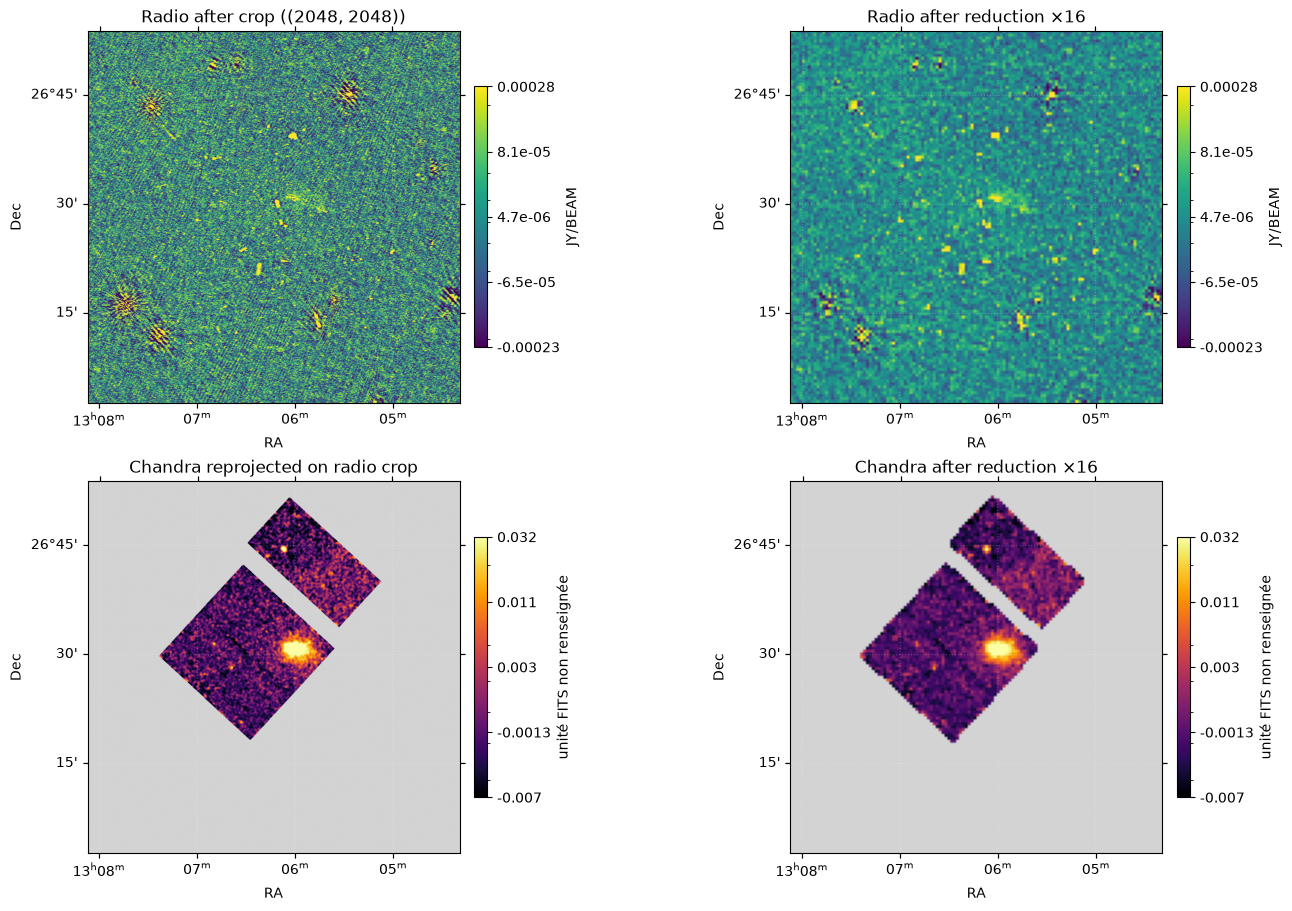

In [11]:
raw_small = block_average(raw_crop, factor)
if has_chandra:
    chandra_projected, footprint = reproject_interp(
        (chandra_native.astype(np.float32), chandra_wcs), window_wcs,
        shape_out=raw_crop.shape, order="bilinear")
    chandra_projected[footprint <= 0] = np.nan
    chandra_small = block_average(chandra_projected, factor)
    chandra_mask = np.isfinite(chandra_small)
    print(f"Couverture Chandra avant réduction : {np.isfinite(chandra_projected).mean():.1%}")
    print(f"Couverture Chandra après réduction : {chandra_mask.mean():.1%}")
    if not chandra_mask.any():
        print("Pas de recouvrement : image Chandra normalisée et masque seront entièrement nuls.")
else:
    chandra_projected = footprint = chandra_small = chandra_mask = None

if VERIFY_CACHE:
    cached, cache_status = load_processed(info, "pair" if has_chandra else "raw", SIZE,
                                           PROCESSED_DIR, return_status=True)
    np.testing.assert_allclose(raw_small, cached["raw"], equal_nan=True)
    if has_chandra:
        np.testing.assert_allclose(chandra_small, cached["chandra"], equal_nan=True)
        np.testing.assert_array_equal(chandra_mask, cached["chandra_mask"])
    print(f"Cache : {cache_status}. Images identiques à la chaîne de prétraitement.")

fig = plt.figure(figsize=(14, 9 if has_chandra else 4.5), layout="constrained")
rows = 2 if has_chandra else 1
radio_scale = display_norm(raw_crop)
panel(fig, rows, 2, 1, raw_crop, f"Radio after crop ({raw_crop.shape})", window_wcs, raw_unit, norm=radio_scale)
panel(fig, rows, 2, 2, raw_small, f"Radio after reduction ×{factor}", small_wcs, raw_unit, norm=radio_scale)
if has_chandra:
    x_scale = display_norm(chandra_projected)
    panel(fig, rows, 2, 3, chandra_projected, "Chandra reprojected on radio crop",
          window_wcs, chandra_unit, "inferno", x_scale)
    panel(fig, rows, 2, 4, chandra_small, f"Chandra after reduction ×{factor}",
          small_wcs, chandra_unit, "inferno", x_scale)
show_figure(fig, "02_preprocessing.png")

## 3. Normalisation pour le modèle

Sur les pixels finis (et couverts pour Chandra) : percentiles bas/haut, clipping
dans `[0,1]`, puis `asinh(alpha × valeur) / asinh(alpha)`. Les pixels invalides
sont remplis par zéro. Un zéro normalisé peut donc correspondre au fond ou à
une absence de données : le masque Chandra conserve cette distinction.
Ici les images normalisées sont affichées linéairement avec une échelle fixe `[0,1]`.

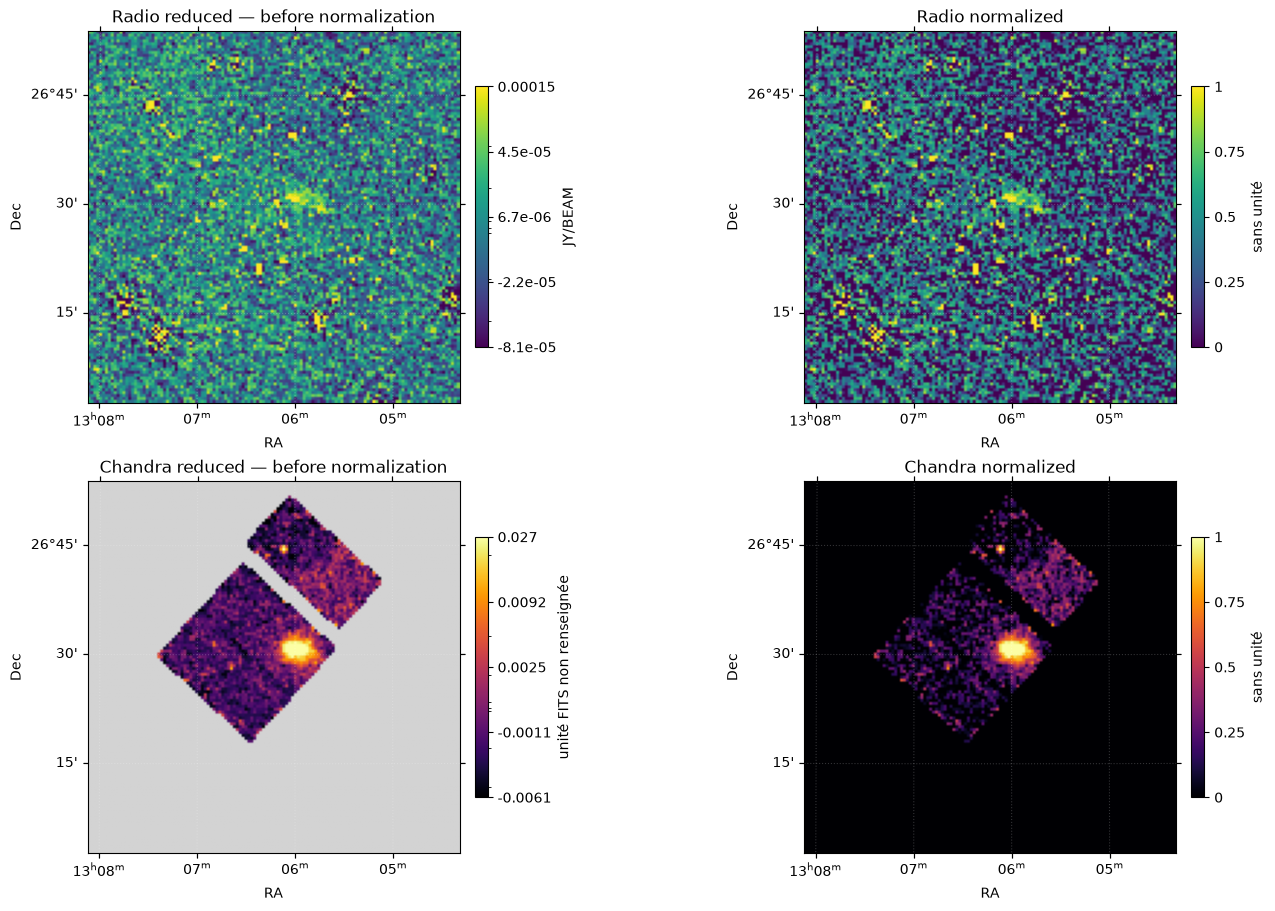

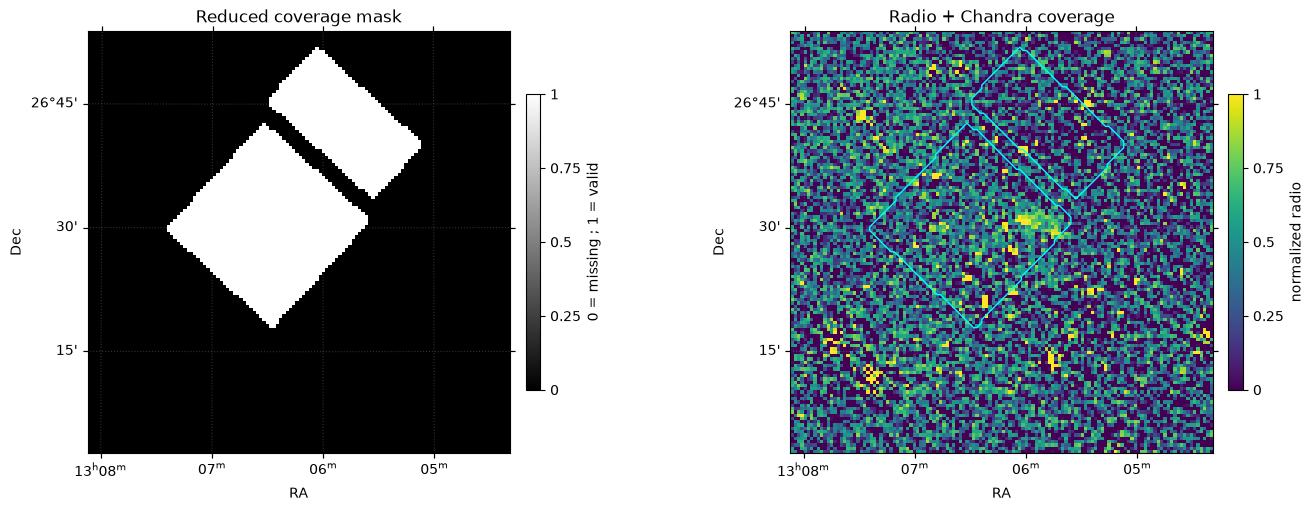

In [12]:
norm_parameters = dict(percentile_lo=PERCENTILE_LO, percentile_hi=PERCENTILE_HI, alpha=ALPHA)
raw_normalized = normalize(raw_small, **norm_parameters)
chandra_normalized = normalize(chandra_small, mask=chandra_mask, **norm_parameters) if has_chandra else None
fig = plt.figure(figsize=(14, 9 if has_chandra else 4.5), layout="constrained")
panel(fig, rows, 2, 1, raw_small, "Radio reduced — before normalization", small_wcs, raw_unit)
panel(fig, rows, 2, 2, raw_normalized, "Radio normalized", small_wcs, "sans unité", norm=Normalize(0, 1))
if has_chandra:
    panel(fig, rows, 2, 3, chandra_small, "Chandra reduced — before normalization", small_wcs, chandra_unit, "inferno")
    panel(fig, rows, 2, 4, chandra_normalized, "Chandra normalized", small_wcs, "sans unité", "inferno", Normalize(0, 1))
show_figure(fig, "03_normalization.png")

if has_chandra:
    fig = plt.figure(figsize=(14, 5), layout="constrained")
    panel(fig, 1, 2, 1, chandra_mask.astype(float), "Reduced coverage mask", small_wcs,
          "0 = missing ; 1 = valid", "gray", Normalize(0, 1))
    ax = panel(fig, 1, 2, 2, raw_normalized, "Radio + Chandra coverage", small_wcs,
               "normalized radio", norm=Normalize(0, 1))
    if chandra_mask.any() and not chandra_mask.all():
        ax.contour(chandra_mask.astype(float), levels=[.5], colors="cyan", linewidths=1)
    show_figure(fig, "04_coverage.png")

## 4. Distributions et statistiques

Les histogrammes excluent les pixels sans données. Les lignes verticales marquent
les seuils de normalisation. Les statistiques gardent les valeurs finies sans
clipping ; les valeurs affichées hors de l’échelle de couleur ne sont pas supprimées.

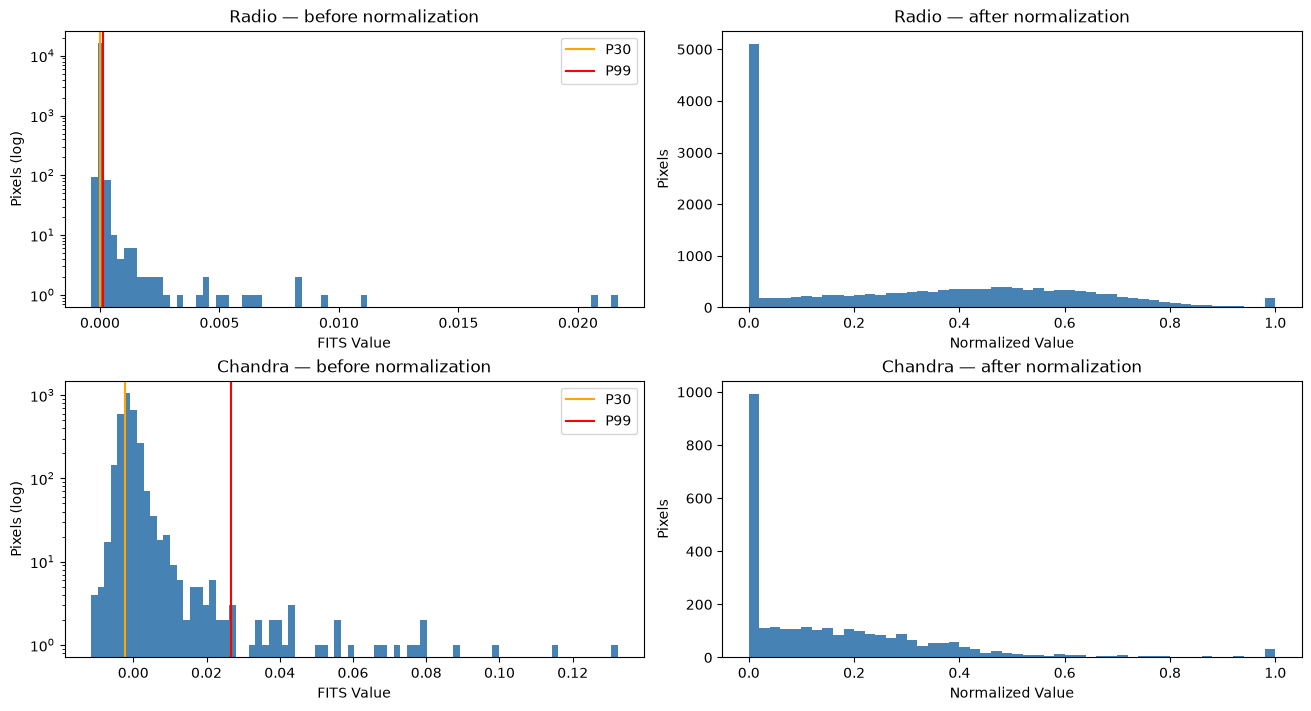

étape,forme,fraction_finie,minimum,médiane,maximum
str19,str12,float64,float64,float64,float64
Radio native,"(2304, 2304)",1.0,-0.003879138035699725,3.8466588136998325e-07,0.23127815127372742
Radio crop,"(2048, 2048)",1.0,-0.0026321716140955687,9.311382882515318e-07,0.23127815127372742
Radio reduced,"(128, 128)",1.0,-0.0003776077937800437,1.2247979839230538e-06,0.021653160452842712
Radio normalized,"(128, 128)",1.0,0.0,0.2891547381877899,1.0
Chandra native,"(1363, 1246)",0.43098089970075926,-0.014535054894558462,-0.0013722111882110664,0.15078832769125464
Chandra reprojected,"(2048, 2048)",0.16816329956054688,-0.014518680415195833,-0.0013714744262636027,0.15073573094116005
Chandra reduced,"(128, 128)",0.180419921875,-0.01155348215252161,-0.0013826781651005149,0.13222405314445496
Chandra normalized,"(128, 128)",1.0,0.0,0.0,1.0


In [14]:
modalities = [("Radio", raw_small, raw_normalized, np.isfinite(raw_small))]
if has_chandra:
    modalities.append(("Chandra", chandra_small, chandra_normalized, chandra_mask))
fig, axes = plt.subplots(len(modalities), 2, figsize=(13, 3.5 * len(modalities)),
                         squeeze=False, layout="constrained")
for i, (name, physical, normalized, valid) in enumerate(modalities):
    values = physical[valid & np.isfinite(physical)]
    if values.size:
        axes[i, 0].hist(values, bins=80, color="steelblue")
        for percentile, color in ((PERCENTILE_LO, "orange"), (PERCENTILE_HI, "red")):
            axes[i, 0].axvline(np.percentile(values, percentile), color=color, label=f"P{percentile}")
        axes[i, 0].set_yscale("log")
        axes[i, 0].legend()
        axes[i, 1].hist(normalized[valid], bins=50, range=(0, 1), color="steelblue")
    else:
        axes[i, 0].text(.5, .5, "No valid pixels", ha="center", transform=axes[i, 0].transAxes)
    axes[i, 0].set(title=f"{name} — before normalization", xlabel="FITS Value", ylabel="Pixels (log)")
    axes[i, 1].set(title=f"{name} — after normalization", xlabel="Normalized Value", ylabel="Pixels")
show_figure(fig, "05_histograms.png")

stages = [("Radio native", raw_native), ("Radio crop", raw_crop),
          ("Radio reduced", raw_small), ("Radio normalized", raw_normalized)]
if has_chandra:
    stages += [("Chandra native", chandra_native), ("Chandra reprojected", chandra_projected),
               ("Chandra reduced", chandra_small), ("Chandra normalized", chandra_normalized)]
statistics = []
for name, data in stages:
    finite = data[np.isfinite(data)]
    statistics.append(dict(étape=name, forme=str(data.shape), fraction_finie=float(np.isfinite(data).mean()),
        minimum=float(finite.min()) if finite.size else None,
        médiane=float(np.median(finite)) if finite.size else None,
        maximum=float(finite.max()) if finite.size else None))
display(Table(rows=statistics))
if EXPORT_FIGURES:
    report = dict(cluster=info, size=SIZE, factor=factor, normalization=norm_parameters,
                  chandra_coverage=float(chandra_mask.mean()) if has_chandra else None, statistics=statistics)
    (OUTPUT_DIR / "report.json").write_text(json.dumps(report, indent=2, ensure_ascii=False, allow_nan=False))
    print("Figures et statistiques exportées :", OUTPUT_DIR)

Pour analyser un autre amas, modifier `CLUSTER_ID` puis **redémarrer le noyau et
exécuter toutes les cellules**. Pour étudier uniquement la normalisation, modifier
les percentiles/alpha et réexécuter les cellules de la section 3 puis de la section 4.
Les figures ne suffisent pas à valider scientifiquement les paramètres de traitement :
les unités, la résolution instrumentale et la couverture sont propres à chaque observation.